In [1]:
# load packages
import os
import pandas as pd
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import mlflow
import mlflow.xgboost
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

from Library.data_preprocessor import DataPreprocessor
from Library.help_function import ModelHelper

/home/adam/github/tv-audience-forecasting/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# load data
data_path = os.path.join(project_root, 'raw_data.csv')
df = pd.read_csv(data_path, low_memory=False)
df['timeslot_datetime_from'] = pd.to_datetime(df['timeslot_datetime_from'])

# --- IMPLEMENTATION ---
FIX_COLS = ['main_ident', 'timeslot_datetime_from', 'channel_id', 'share_15_54', 'share_15_54_3mo_mean']
TARGET = 'share_15_54'

preprocessor = DataPreprocessor(FIX_COLS, TARGET)
processed_df = preprocessor.run(df)



[I 2026-03-09 12:11:13,880] A new study created in memory with name: no-name-248de8d3-7b78-4d3a-affe-bb2a13e08db1


Zahajuji tuning s 15 pokusy...


[I 2026-03-09 12:11:14,618] Trial 0 finished with value: 5.529653859358067 and parameters: {'n_estimators': 234, 'max_depth': 4, 'learning_rate': 0.03806380562669997, 'subsample': 0.824963805323832, 'colsample_bytree': 0.9703263980831439}. Best is trial 0 with value: 5.529653859358067.
[I 2026-03-09 12:11:15,309] Trial 1 finished with value: 5.441457074233277 and parameters: {'n_estimators': 378, 'max_depth': 3, 'learning_rate': 0.06953587686380562, 'subsample': 0.936391885923745, 'colsample_bytree': 0.8572278378206591}. Best is trial 1 with value: 5.441457074233277.
[I 2026-03-09 12:11:15,968] Trial 2 finished with value: 5.722898602467981 and parameters: {'n_estimators': 225, 'max_depth': 5, 'learning_rate': 0.061666817315319984, 'subsample': 0.7123916692610467, 'colsample_bytree': 0.7129997192874248}. Best is trial 1 with value: 5.441457074233277.
[I 2026-03-09 12:11:17,141] Trial 3 finished with value: 5.926555235442856 and parameters: {'n_estimators': 297, 'max_depth': 6, 'learnin

Fold 1 | MAE: 5.8806 | AdjR2: 0.1769
Fold 2 | MAE: 3.0841 | AdjR2: 0.2389
Fold 3 | MAE: 4.4195 | AdjR2: -1.1663
Fold 4 | MAE: 2.1528 | AdjR2: -0.1092
Fold 5 | MAE: 1.4544 | AdjR2: 0.0344

FINÁLNÍ PRŮMĚRNÁ MAE: 3.3983
FINÁLNÍ PRŮMĚRNÝ ADJUSTED R2: -0.1651


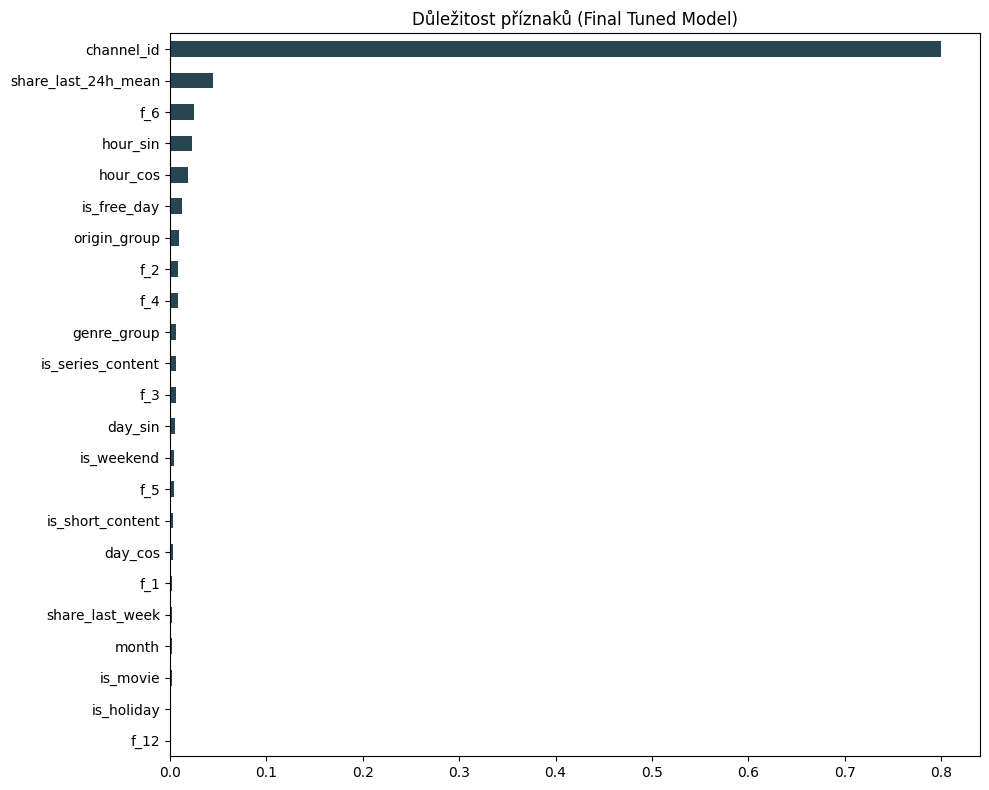

In [3]:
# --- 1. NAČTENÍ A PŘÍPRAVA DAT (Zůstává stejné) ---
df = processed_df.copy()
df = df.sort_values(['channel_id', 'timeslot_datetime_from']).reset_index(drop=True)

# --- 2. FEATURE ENGINEERING ---
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

if df['day_of_week'].dtype == 'object' or df['day_of_week'].dtype.name == 'category':
    day_map = {'Monday':0, 'Tuesday':1, 'Wednesday':2, 'Thursday':3, 'Friday':4, 'Saturday':5, 'Sunday':6}
    df['day_num'] = df['day_of_week'].map(day_map)
else:
    df['day_num'] = df['day_of_week']

df['day_sin'] = np.sin(2 * np.pi * df['day_num'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['day_num'] / 7)

df['share_last_week'] = df.groupby('channel_id')['share_15_54'].shift(168)
df['share_last_24h_mean'] = df.groupby('channel_id')['share_15_54'].transform(
    lambda x: x.shift(1).rolling(window=24, min_periods=1).mean()
)

for col in ['channel_id', 'genre_group', 'origin_group']:
    df[col] = df[col].astype('category').cat.codes
df = df.ffill().bfill()

forbidden = ['share_15_54', 'share_15_54_3mo_mean', 'timeslot_datetime_from', 'main_ident',
             'f_7', 'f_8', 'f_9', 'f_10', 'f_11', 'hour', 'day_of_week', 'day_num']

features = [col for col in df.columns if col not in forbidden]
X = df[features]
y = df['share_15_54']

# --- 3. ML WORKFLOW S VYUŽITÍM HELPERU ---
helper = ModelHelper(X, y)

# Volitelně: spuštění tuningu
best_params = helper.run_tuning(n_trials=15)

mlflow.set_experiment("TV_Sledovanost_Task_2_Final")
with mlflow.start_run(run_name="XGBoost_WithOut_3Mo_Mean"):
    
    mlflow.log_params(best_params)
    mlflow.log_param("num_features", helper.features_count)

    tscv = TimeSeriesSplit(n_splits=5)
    model = xgb.XGBRegressor(**best_params, n_jobs=-1)
    
    maes, r2s, adj_r2s = [], [], []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        
        m_mae = mean_absolute_error(y_test, preds)
        m_r2 = r2_score(y_test, preds)
        m_adj_r2 = helper.calculate_adjusted_r2(m_r2, len(y_test), helper.features_count)
        
        maes.append(m_mae)
        r2s.append(m_r2)
        adj_r2s.append(m_adj_r2)
        
        mlflow.log_metric(f"fold_{fold+1}_mae", m_mae)
        mlflow.log_metric(f"fold_{fold+1}_adj_r2", m_adj_r2)
        print(f"Fold {fold+1} | MAE: {m_mae:.4f} | AdjR2: {m_adj_r2:.4f}")

    # Logování průměrů
    mlflow.log_metric("avg_mae", np.mean(maes))
    mlflow.log_metric("avg_adj_r2", np.mean(adj_r2s))

    # Artefakty a uložení
    importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)
    plt.figure(figsize=(10, 8))
    importances.plot(kind='barh', color='#264653')
    plt.title('Důležitost příznaků (Final Tuned Model)')
    plt.tight_layout()
    plt.savefig("feature_importance.png")
    mlflow.log_artifact("feature_importance.png")
    mlflow.xgboost.log_model(model, name="xgboost_baseline_no_3mo")

    print(f"\nFINÁLNÍ PRŮMĚRNÁ MAE: {np.mean(maes):.4f}")
    print(f"FINÁLNÍ PRŮMĚRNÝ ADJUSTED R2: {np.mean(adj_r2s):.4f}")

In [4]:
import mlflow
runs = mlflow.search_runs(experiment_names=["TV_Sledovanost_Task_2_Final"])
print(runs[['metrics.avg_mae', 'metrics.avg_adj_r2']])

   metrics.avg_mae  metrics.avg_adj_r2
0         3.398283           -0.165064


[I 2026-03-09 12:12:21,923] A new study created in memory with name: no-name-88b156c5-273a-48ff-bb43-e710ecd8500c


--- Zahajuji Task 3: Model s využitím 3M průměru ---
Zahajuji tuning s 10 pokusy...


[I 2026-03-09 12:12:23,199] Trial 0 finished with value: 5.957957456750273 and parameters: {'n_estimators': 147, 'max_depth': 7, 'learning_rate': 0.010863572394478863, 'subsample': 0.9699718378967961, 'colsample_bytree': 0.7401071192094902}. Best is trial 0 with value: 5.957957456750273.
[I 2026-03-09 12:12:24,812] Trial 1 finished with value: 4.356021747512908 and parameters: {'n_estimators': 215, 'max_depth': 7, 'learning_rate': 0.04206269060456572, 'subsample': 0.9141687665566014, 'colsample_bytree': 0.9157244455624834}. Best is trial 1 with value: 4.356021747512908.
[I 2026-03-09 12:12:26,550] Trial 2 finished with value: 4.488960335187168 and parameters: {'n_estimators': 137, 'max_depth': 8, 'learning_rate': 0.04660351027318939, 'subsample': 0.9681100133575226, 'colsample_bytree': 0.9137591132292233}. Best is trial 1 with value: 4.356021747512908.
[I 2026-03-09 12:12:28,598] Trial 3 finished with value: 4.780020611215964 and parameters: {'n_estimators': 265, 'max_depth': 7, 'learn

Task 3 - Průměrná MAE: 2.8591
Task 3 - MAE posledního měsíce: 1.4062


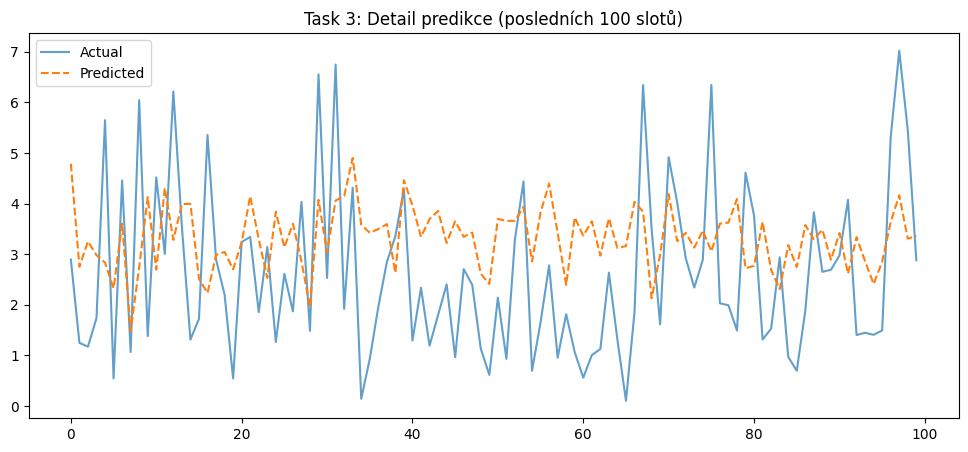

In [5]:
# --- PŘÍPRAVA DAT PRO TASK 3 ---
# Rozdíl oproti Task 2: PONECHÁME 'share_15_54_3mo_mean'
forbidden_t3 = [
    'share_15_54', 'timeslot_datetime_from', 'main_ident',
    'f_7', 'f_8', 'f_9', 'f_10', 'f_11', 'hour', 'day_of_week', 'day_num'
]

features_t3 = [col for col in df.columns if col not in forbidden_t3]
X_t3 = df[features_t3]
y_t3 = df['share_15_54']

print(f"--- Zahajuji Task 3: Model s využitím 3M průměru ---")
helper_t3 = ModelHelper(X_t3, y_t3)

# 1. Tuning pro Task 3 (parametry se mohou lišit, když máme silný baseline)
best_params_t3 = helper_t3.run_tuning(n_trials=10)

mlflow.set_experiment("TV_Sledovanost_Task_3_Final")
with mlflow.start_run(run_name="XGBoost_With_3Mo_Mean"):
    
    mlflow.log_params(best_params_t3)
    mlflow.log_param("task", "Task 3 - Enhanced with 3Mo Mean")

    # TimeSeriesSplit - budeme se soustředit na poslední měsíc (Fold 5)
    tscv = TimeSeriesSplit(n_splits=5)
    model_t3 = xgb.XGBRegressor(**best_params_t3)
    
    maes, adj_r2s = [], []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X_t3)):
        X_train, X_test = X_t3.iloc[train_idx], X_t3.iloc[test_idx]
        y_train, y_test = y_t3.iloc[train_idx], y_t3.iloc[test_idx]
        
        model_t3.fit(X_train, y_train)
        preds = model_t3.predict(X_test)
        
        m_mae = mean_absolute_error(y_test, preds)
        m_r2 = r2_score(y_test, preds)
        m_adj_r2 = helper_t3.calculate_adjusted_r2(m_r2, len(y_test), helper_t3.features_count)
        
        maes.append(m_mae)
        adj_r2s.append(m_adj_r2)
        
        # Speciální logování pro poslední měsíc (Fold 5)
        if fold == 4:
            mlflow.log_metric("last_month_mae", m_mae)
            mlflow.log_metric("last_month_adj_r2", m_adj_r2)
            
            # Graf pro interpretaci Task 3
            plt.figure(figsize=(12, 5))
            plt.plot(y_test.values[-100:], label='Actual', alpha=0.7)
            plt.plot(preds[-100:], label='Predicted', linestyle='--')
            plt.title('Task 3: Detail predikce (posledních 100 slotů)')
            plt.legend()
            plt.savefig("task3_last_month_detail.png")
            mlflow.log_artifact("task3_last_month_detail.png")

    mlflow.log_metric("avg_mae", np.mean(maes))
    mlflow.xgboost.log_model(model_t3, name="xgboost_enhanced_with_3mo")

    print(f"Task 3 - Průměrná MAE: {np.mean(maes):.4f}")
    print(f"Task 3 - MAE posledního měsíce: {maes[-1]:.4f}")